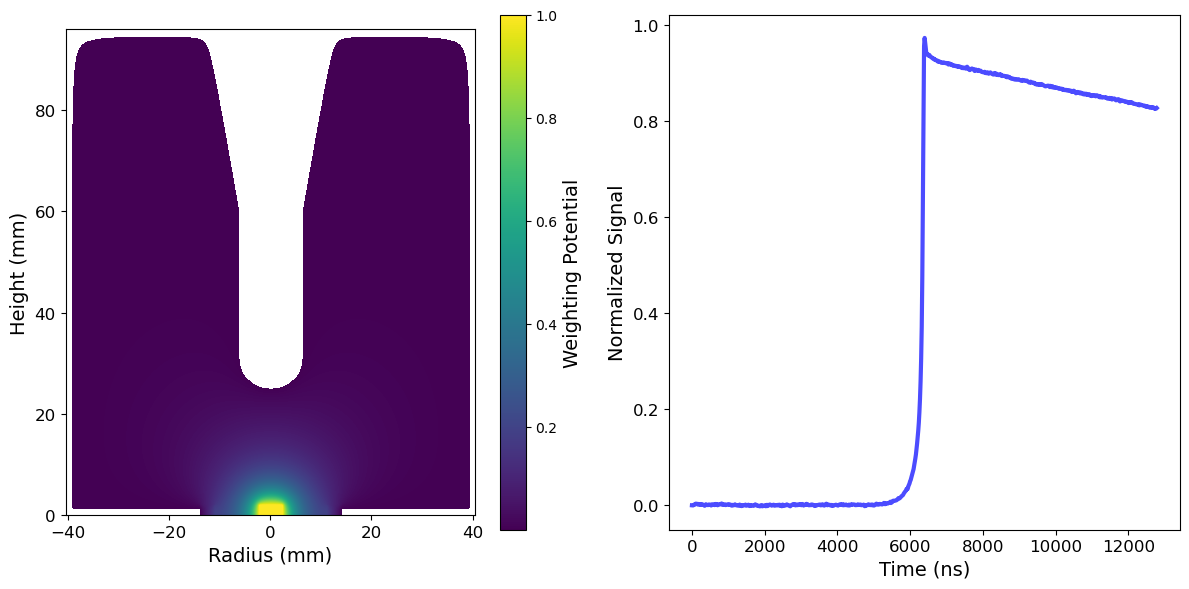

In [1]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy.interpolate as interp
import torch

xlim=200*16
xmax=550*16
# Clear the current session and reload the saved data to verify
loaded_data = np.load("/nas/longleaf/home/kbhimani/CPU-Net/plot_data/waveform_data.npy", allow_pickle=True).item()
# Accessing the data
loaded_detector_pulse = loaded_data["detector_pulse"]

num_samples = len(loaded_detector_pulse)

# Create a new array for time, assuming samples are spaced 16 ns apart
time_array = np.arange(0, num_samples * 16, 16)  # Time in nanoseconds


det='V06649A'
# Load data
field_dir = f'/nas/longleaf/home/kbhimani/ornl_sims/icpc_siggen/fields/wp_{det}.dat'
# field_dir= '/work/users/k/b/kbhimani/EH-Drift_data/wp/wp_P00698A_sc0.00_grid0.0200.dat'
data = np.loadtxt(field_dir)

# Extract and sort unique x, y values to ensure correct reshaping
x = np.sort(np.unique(data[:, 0]))
y = np.sort(np.unique(data[:, 1]))
z = data[:, 2]  # Column 3 = field, Column 2 = potential

# Reshape z into a grid
zvals = z.reshape(len(x), len(y)).T  # Transpose to match x-y ordering

# Set very small values to NaN to prevent issues in LogNorm
zvals[zvals < 1e-6] = np.nan  # Ensures near-zero values don't appear in log scale

# Create a symmetric full detector image (mirroring negative radial values)
zvals_neg = np.fliplr(zvals)
zvals_full = np.hstack((zvals_neg, zvals))

# Define plot boundaries
bounds = (-1 * max(x), max(x), min(y), max(y))

# Create subplots: one for the weighting potential, one for the detector pulse
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

### **Left Plot: Weighting Potential Heatmap**
ax1 = axes[0]
im = ax1.imshow(zvals_full, 
                vmin=1e-5, vmax=np.nanmax(zvals),  # Ensures 0 is white
                extent=bounds, 
                origin="lower", 
                cmap='viridis',  # Colorblind-friendly colormap
                interpolation='bilinear')

# Labels and colorbar
ax1.set_xlabel("Radius (mm)", size=14)
ax1.set_ylabel("Height (mm)", size=14)
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Weighting Potential", size=14)
# ax1.set_title("Weighting Potential", size=14)

### **Right Plot: Detector Pulse**
ax2 = axes[1]
ax2.plot(time_array, loaded_detector_pulse, alpha=0.7, color="blue", linewidth=3)

# Labels and legend
ax2.set_xlabel("Time (ns)", size=14)
ax2.set_ylabel("Normalized Signal", size=14)
# ax2.set_title("Detector Pulse", size=14)

ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

# Save figure
plt.tight_layout()
plt.savefig('figs/wp_det.pdf')
plt.show()

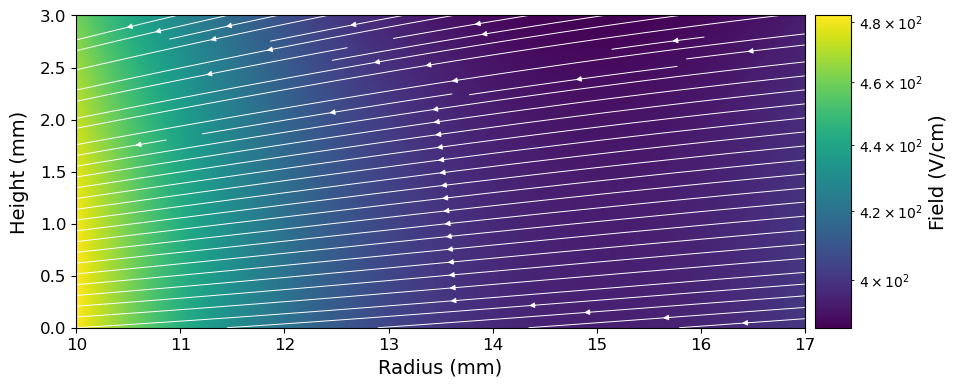

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'

detector = 'ponama_1'
sc_plot_1 = -0.5 #0.5
## Load data (Ensure `field_dir` is defined)
data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc={sc_plot_1:.4f}.dat')

# Extracting unique X, Y, and the Z values (field/potential)
x = np.unique(data[:, 0])  # Unique radial positions
y = np.unique(data[:, 1])  # Unique axial positions
z = data[:, 3]             # Field values # column 3 = field, 2 = potential
E_r = data[:, 4]           # Radial electric field (V/cm)
E_z = data[:, 5]           # Axial electric field (V/cm)

# Reshape Z, E_r, and E_z into grids
zvals = z.reshape(len(x), len(y))
zvals[zvals < 0] = 0       # Set negative potential values to 0
E_r_vals = E_r.reshape(len(x), len(y))
E_z_vals = E_z.reshape(len(x), len(y))

# Define the range for r and z
r_min, r_max = 10, 17
z_min, z_max = 0, 3

# Create masks to select the subregion
mask_x = (x >= r_min) & (x <= r_max)
mask_y = (y >= z_min) & (y <= z_max)

# Apply masks to x, y, and create a new meshgrid
x_sub = x[mask_x]
y_sub = y[mask_y]
X_sub, Y_sub = np.meshgrid(x_sub, y_sub, indexing='xy')

# Slice the corresponding zvals, E_r_vals, and E_z_vals
zvals_sub = zvals[mask_x][:, mask_y]
E_r_vals_sub = E_r_vals[mask_x][:, mask_y]
E_z_vals_sub = E_z_vals[mask_x][:, mask_y]

# Set near-zero values to NaN to remove grainy areas
zvals_sub[zvals_sub <= 1e-10] = np.nan  

# Define plot bounds for the restricted range
bounds = (r_min, r_max, z_min, z_max)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# Use a custom colormap that handles NaNs properly
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')  

# Create a divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust `size` and `pad` for better spacing

# Plot the potential map with LogNorm and corrected colormap
ip = ax.imshow(zvals_sub.T, norm=colors.LogNorm(),
               extent=bounds, origin="lower", cmap=cmap,
               interpolation='bilinear')

# Add a properly scaled colorbar
cbar = plt.colorbar(ip, cax=cax)
cbar.set_label("Field (V/cm)", size=14)
cbar.ax.tick_params(labelsize=11)  # Adjust font size of colorbar ticks

# Overlay electric field lines
ax.streamplot(X_sub, Y_sub, E_r_vals_sub.T, E_z_vals_sub.T,
              color='white', linewidth=0.7, density=1, arrowsize=0.8)

# Add labels and title
ax.set_xlabel("Radius (mm)", size=14)
ax.set_ylabel("Height (mm)", labelpad=8, size=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_title(f"Field Magnitude with Electric Field Lines for {detector} sc= {sc_plot_1}e10 e/cm²", size=14)

# Save & Show
plt.savefig(f'figs/elect_field_lines_surface_{detector}_sc_{sc_plot_1}.pdf', dpi=100)
plt.show()


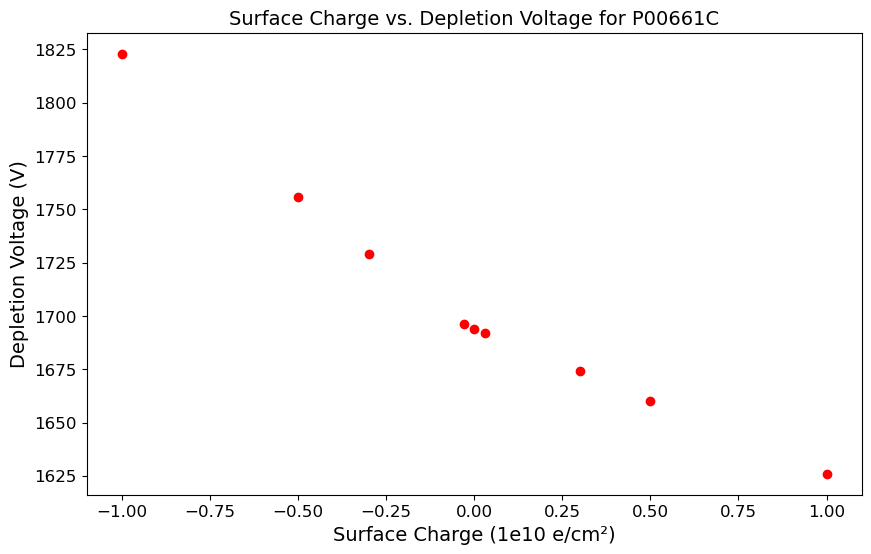

In [3]:
# Data
# surface_charge = [0, -0.30, -1.0, -0.03, -0.50, 0.03, 0.30, 0.50, 1.00]
# depletion_voltage = [1903, 1927, 2021, 1905, 1954, 1901, 1883, 1869, 1835] 
surface_charge = [0, -0.30, -1.0, -0.03, -0.50, 0.03, 0.30, 0.50, 1.00]
depletion_voltage = [1694, 1729, 1823, 1696, 1756, 1692, 1674, 1660, 1626]
import matplotlib.pyplot as plt

bias_voltage = 2170

# Plot
plt.figure(figsize=(10, 6))
plt.plot(surface_charge, depletion_voltage,'ro',markersize=6)
# plt.axhline(y=bias_voltage, color='red', linestyle='--', label=f'SCARF Operating Voltage {bias_voltage}V')

# Labels and Title
plt.xlabel('Surface Charge (1e10 e/cm²)', fontsize=14)
plt.ylabel('Depletion Voltage (V)', fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
plt.title('Surface Charge vs. Depletion Voltage for P00661C', fontsize=14)
# plt.grid(True)
plt.savefig('figs/deplep_sc.pdf',dpi=300)
# Display Plot
plt.show()


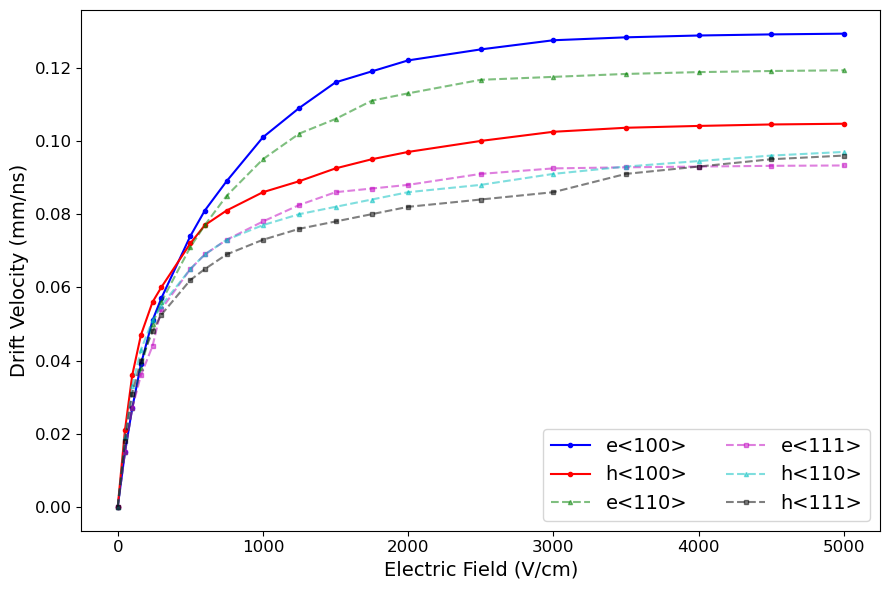

In [4]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt

############################################################################
# 1) PIECEWISE e<100>, h<100>
############################################################################

drift_E = np.array([
    0.0,   100., 160., 240., 300., 500., 600.,
    750., 1000., 1250., 1500., 1750., 2000., 2500.,
    3000., 3500., 4000., 4500., 5000.
], dtype=float)

drift_offset_e = np.array([
    0.0,   0.027, 0.038, 0.049, 0.055, 0.074, 0.081,
    0.089, 0.101, 0.109, 0.116, 0.119, 0.122, 0.125,
    0.1275,0.1283,0.1288,0.1291,0.1293
], dtype=float)

drift_offset_h = np.array([
    0.0,   0.036, 0.047, 0.056, 0.060, 0.072, 0.077,
    0.081, 0.086, 0.089, 0.0925,0.095, 0.097, 0.100,
    0.1025,0.1036,0.1041,0.1045,0.1047
], dtype=float)

# Compute slopes for each sub-interval
drift_slope_e = np.zeros(len(drift_E) - 1, dtype=float)
drift_slope_h = np.zeros(len(drift_E) - 1, dtype=float)
for i in range(len(drift_E) - 1):
    dE = drift_E[i+1] - drift_E[i]
    drift_slope_e[i] = (drift_offset_e[i+1] - drift_offset_e[i]) / dE
    drift_slope_h[i] = (drift_offset_h[i+1] - drift_offset_h[i]) / dE

def piecewise_drift_velocity(E, E_array, offset_array, slope_array):
    """Returns the drift velocity at field E via piecewise linear segments."""
    if E < E_array[0]:
        return offset_array[0]
    if E >= E_array[-1]:
        return offset_array[-1]
    for i in range(len(E_array) - 1):
        if E_array[i] <= E < E_array[i+1]:
            return offset_array[i] + slope_array[i]*(E - E_array[i])
    return offset_array[-1]

# Generate a fine E array for plotting piecewise lines
E_plot = np.linspace(0, 5000, 500)
vE_e = [piecewise_drift_velocity(e, drift_E, drift_offset_e, drift_slope_e) for e in E_plot]
vE_h = [piecewise_drift_velocity(e, drift_E, drift_offset_h, drift_slope_h) for e in E_plot]


############################################################################
# 2) RAW DATA for e<100>, e<110>, e<111>, h<100>, h<110>, h<111>
############################################################################

# Format: E, e100, e110, e111, h100, h110, h111
data = np.array([
    [   0,     0.0,    0.0,    0.0,    0.0,    0.0,    0.0   ],
    [  50,     0.015,  0.015,  0.015,  0.021,  0.019,  0.018 ],
    [ 100,     0.027,  0.027,  0.027,  0.036,  0.033,  0.031 ],
    [ 160,     0.039,  0.038,  0.036,  0.047,  0.043,  0.040 ],
    [ 240,     0.051,  0.050,  0.044,  0.056,  0.051,  0.048 ],
    [ 300,     0.057,  0.056,  0.054,  0.060,  0.055,  0.0525],
    [ 500,     0.074,  0.071,  0.065,  0.072,  0.065,  0.062 ],
    [ 600,     0.081,  0.077,  0.069,  0.077,  0.069,  0.065 ],
    [ 750,     0.089,  0.085,  0.073,  0.081,  0.073,  0.069 ],
    [1000,     0.101,  0.095,  0.078,  0.086,  0.077,  0.073 ],
    [1250,     0.109,  0.102,  0.0825, 0.089,  0.080,  0.076 ],
    [1500,     0.116,  0.106,  0.086,  0.0925, 0.082,  0.078 ],
    [1750,     0.119,  0.111,  0.087,  0.095,  0.084,  0.080 ],
    [2000,     0.122,  0.113,  0.088,  0.097,  0.086,  0.082 ],
    [2500,     0.125,  0.1167, 0.091,  0.100,  0.088,  0.084 ],
    [3000,     0.1275, 0.1175, 0.0925, 0.1025, 0.091,  0.086 ],
    [3500,     0.1283, 0.1183, 0.0928, 0.1036, 0.093,  0.091 ],
    [4000,     0.1288, 0.1188, 0.0930, 0.1041, 0.0945, 0.093 ],
    [4500,     0.1291, 0.1191, 0.0932, 0.1045, 0.096,  0.095 ],
    [5000,     0.1293, 0.1193, 0.0933, 0.1047, 0.097,  0.096 ],
], dtype=float)

Evals = data[:, 0]
e100_dat = data[:, 1]
e110_dat = data[:, 2]
e111_dat = data[:, 3]
h100_dat = data[:, 4]
h110_dat = data[:, 5]
h111_dat = data[:, 6]


############################################################################
# 3) SINGLE PLOT with piecewise e<100>/h<100> in bold + markers for raw data
############################################################################
plt.figure(figsize=(9,6))

marker_sz = 3

# (A) Bold piecewise lines for e<100>, h<100>
plt.plot(Evals, e100_dat, 'b-o', markersize=marker_sz,  label='e<100>')
plt.plot(Evals, h100_dat, 'r-o', markersize=marker_sz,  label='h<100>')

# (B) Markers for the original tabulated data (all six axes), with reduced markersize
alpha_in = 0.5

plt.plot(Evals, e110_dat, 'g--^', markersize=marker_sz, alpha=alpha_in,  label='e<110>')
plt.plot(Evals, e111_dat, 'm--s', markersize=marker_sz, alpha=alpha_in,  label='e<111>')
plt.plot(Evals, h110_dat, 'c--^', markersize=marker_sz, alpha=alpha_in,  label='h<110>')
plt.plot(Evals, h111_dat, 'k--s', markersize=marker_sz, alpha=alpha_in,  label='h<111>')

# plt.title("Piecewise Linear Drift Velocities vs. Electric Field for Different Crystal Axes", fontsize=14)
plt.xlabel("Electric Field (V/cm)", fontsize=14)
plt.ylabel("Drift Velocity (mm/ns)", fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
plt.legend(loc='lower right', ncol=2, fontsize=14)

plt.tight_layout()
plt.savefig('figs/ehd_dv_e.pdf')
plt.show()


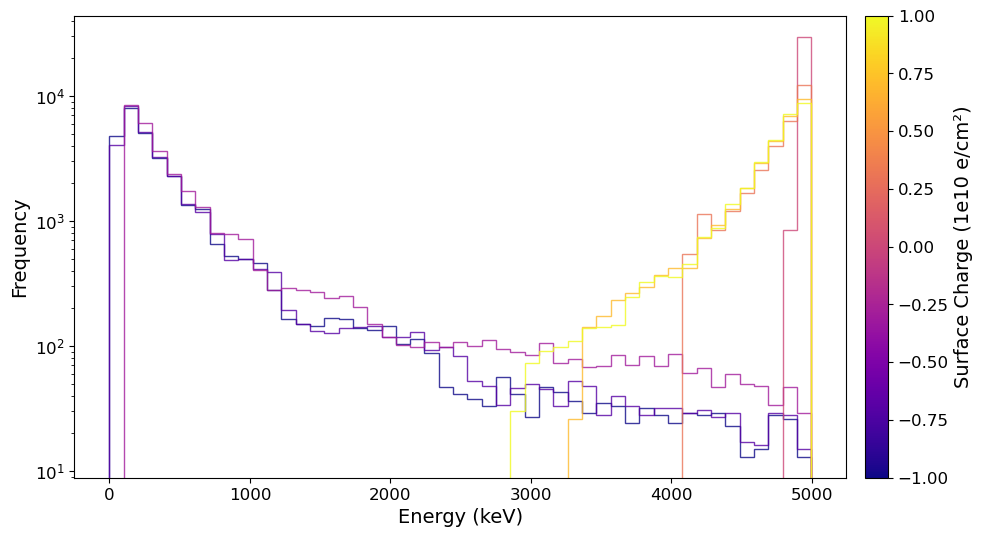

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cmx
import pickle
save_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/eng_hist_plot_data.pkl"

# Load the data
with open(save_path, "rb") as f:
    loaded_data = pickle.load(f)

# Extract the data
loaded_histogram_data = loaded_data["histogram_data"]
loaded_surface_charges = loaded_data["surface_charges"]

# Reverse the colormap
cmap_plot = plt.colormaps.get_cmap('plasma')  # '_r' reverses the colormap

# Normalize surface charges for color mapping
norm = mcolors.Normalize(vmin=min(loaded_surface_charges), vmax=max(loaded_surface_charges))
colormap = cmx.ScalarMappable(norm=norm, cmap=cmap_plot)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create bins for consistent histogram plotting
bins = np.linspace(0, max([max(loaded_histogram_data[sc]) for sc in loaded_histogram_data]), 50)

# Plot histograms with color gradient
for sc_value, e_total_values in loaded_histogram_data.items():
    color = colormap.to_rgba(sc_value)  # Map surface charge to color
    ax.hist(
        e_total_values, bins=bins, alpha=0.8, label=f"SC={sc_value:.1f}", log=True, histtype='step', color=color
    )

# Add a color bar for the surface charges
cbar = fig.colorbar(cmx.ScalarMappable(norm=norm, cmap=cmap_plot), ax=ax, pad=0.02)
cbar.set_label('Surface Charge (1e10 e/cm²)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Add labels, title, legend, and grid
ax.set_xlabel('Energy (keV)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('Histograms of Total Deposited Energy per Event for Different Surface Charges', fontsize=16)
# ax.grid(alpha=0.5)
# ax.legend(title='Surface Charge (SC)', fontsize=10, loc='upper right', ncol=2)
plt.savefig(f"figs/eng_deg_hist.pdf", dpi=100)

# Show the plot
plt.show()

Most ehdrift result are located in ehd_paper notebook. the effiecincy are in EH-Drift/Analysis/ROI_efficiency.ipynb

the degraded beta spectru is at EH-Drift/Analysis/alpha_sims/beta_spectrum.ipynb

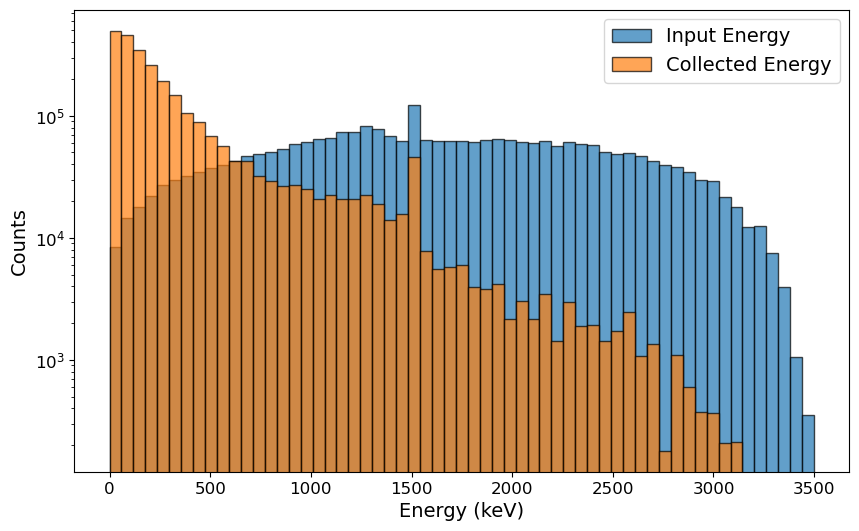

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved histogram data
data = np.load("/nas/longleaf/home/kbhimani/EH-Drift/Analysis/alpha_sims/histogram_k42.npz")
bins = data['bins']
hist_initial = data['hist_initial']
hist_scaled = data['hist_scaled']

# Plot
plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins=bins, weights=hist_initial, alpha=0.7, color='tab:blue', edgecolor='black', label='Input Energy', log=True)
plt.hist(bins[:-1], bins=bins, weights=hist_scaled, alpha=0.7, color='tab:orange', edgecolor='black', label='Collected Energy', log=True)

plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('figs/k_42_beta_spectrum.pdf')
plt.show()


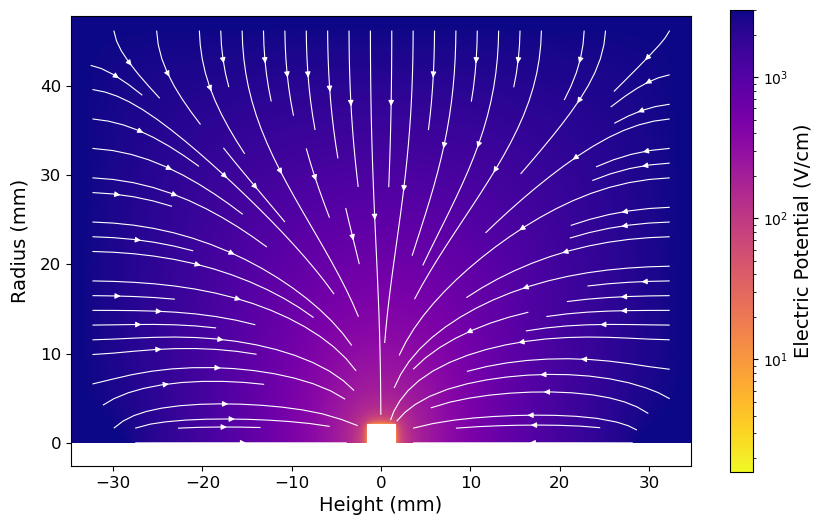

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'
detector = 'P00698A'  # Example detector name

# Load data
data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc=0.0000.dat')

# Extract unique grid points and field data
x = np.unique(data[:, 0])  # Radial positions
y = np.unique(data[:, 1])  # Axial positions
z = data[:, 2]             # Potential values
E_r = data[:, 4]           # Radial electric field
E_z = data[:, 5]           # Axial electric field
 
# Reshape data
zvals = z.reshape(len(x), len(y))
zvals[zvals < 0] = 0  # Replace negative values with 0

# **Fix: Set near-zero values to NaN to remove grainy areas**
zvals[zvals <= 1e-10] = np.nan  # Adjust threshold if needed

# Create a symmetric potential map
zvals_neg = np.fliplr(zvals.T)  # Mirror for negative r-values
zvals_full = np.hstack((zvals_neg, zvals.T))  # Concatenate for full symmetry

# Extend the field values symmetrically
E_r_vals = E_r.reshape(len(x), len(y)).T
E_r_full = np.hstack((-np.fliplr(E_r_vals), E_r_vals))  # Symmetric radial field
E_z_vals = E_z.reshape(len(x), len(y)).T
E_z_full = np.hstack((np.fliplr(E_z_vals), E_z_vals))  # Symmetric axial field

# Create new symmetric grid
x_full = np.linspace(-max(x), max(x), 2 * len(x))  # Symmetric, strictly increasing
y_full = y  # Axial positions remain unchanged
X, Y = np.meshgrid(x_full, y_full)  # Meshgrid for the symmetric grid

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# **Fix: Use a colormap that properly handles NaNs**
cmap = plt.cm.plasma_r.copy()
cmap.set_bad(color='white')  # Hide NaN regions

# Plot potential map with smoother interpolation
bounds = (-1 * max(x), max(x), min(y), max(y))
ip = ax.imshow(zvals_full, norm=colors.LogNorm(),
               extent=bounds, origin="lower", cmap=cmap,
               interpolation='bilinear')  # **Fix: Smooth interpolation**

# Add colorbar
cbar = plt.colorbar(ip, ax=ax)
cbar.ax.set_ylim(cbar.vmin, cbar.vmax)  # Ensure it matches the plot height
cbar.set_label("Electric Potential (V/cm)", fontsize=14)

# Overlay electric field lines
ax.streamplot(X, Y, E_r_full, E_z_full,
              color='white', linewidth=0.8, density=1, arrowsize=0.8)

# Add labels and title
plt.xlabel("Height (mm)", size=14)
plt.ylabel("Radius (mm)", labelpad=8,  size=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
# plt.title(f"Potential Map With Electric Field Lines for {detector}", size=14)
# Save and show
plt.savefig(f'figs/elect_pot_{detector}.pdf')
plt.show()


most GPU results are in the notebook GPU_vs_CPU

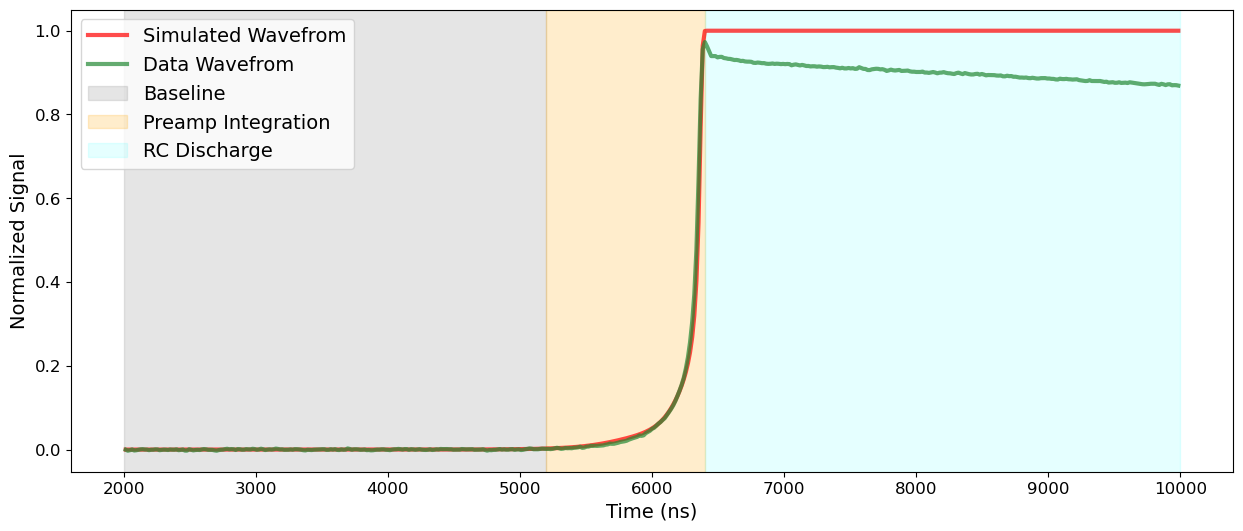

In [8]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import numpy as np
import torch
import matplotlib.pyplot as plt

xlim=200*16
xmax=550*16
# Clear the current session and reload the saved data to verify
loaded_data = np.load("/nas/longleaf/home/kbhimani/CPU-Net/plot_data/waveform_data.npy", allow_pickle=True).item()
# Accessing the data
loaded_detector_pulse = loaded_data["detector_pulse"]
loaded_simulated_pulse = loaded_data["simulated_pulse"]
loaded_translated_pulse = loaded_data["translated_pulse"]
loaded_translated_pulse_inv = loaded_data["translated_pulse_inv"]

num_samples = len(loaded_detector_pulse)

t_l=2000
t_h=10000
time_cut = (time_array > t_l) & (time_array < t_h)

# Create a new array for time, assuming samples are spaced 16 ns apart
time_array = np.arange(0, num_samples * 16, 16)  # Time in nanoseconds



# Plot to verify the loaded data
fig = plt.figure(figsize=(15, 6))
plt.plot(time_array[time_cut], loaded_simulated_pulse[time_cut], label="Simulated Wavefrom", alpha=0.7, color="red", linewidth=3)
plt.plot(time_array[time_cut], loaded_detector_pulse[time_cut], label="Data Wavefrom", alpha=0.7, color="#228833", linewidth=3) #, linestyle=":"
# plt.plot(loaded_translated_pulse, label="ATN Output",color="dodgerblue", linewidth = 2)

plt.axvspan(xmin=2000, xmax=325*16, alpha=0.2, color="grey", label="Baseline")
plt.axvspan(xmin=325*16, xmax=400*16, alpha=0.2, color="orange", label="Preamp Integration")
plt.axvspan(xmin=400*16, xmax=t_h, alpha=0.1, color="cyan", label="RC Discharge")
# plt.xlim(xlim,xmax)
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
plt.savefig("figs/wf_comp_sim_data.pdf", dpi=300)
plt.show()


The hit fig is in ornl_sim file and in sim_post_proc folder
The data vs sim spectrums are in CPU-Net/paper/paper_plot.ipynb notebook

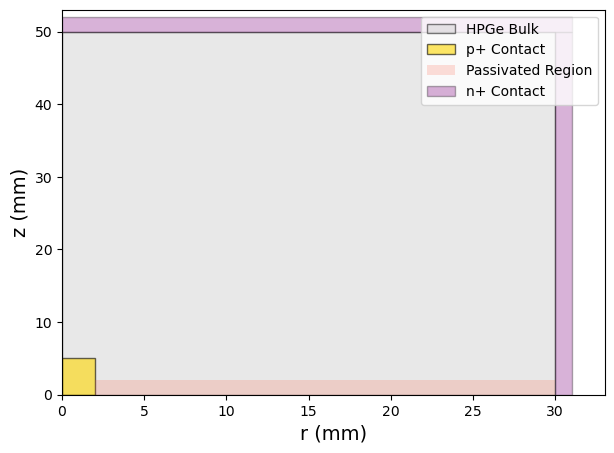

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

"""
Sketch a 2D cross-section of a half-cylinder HPGe detector in (r, z).
The passivated surface starts at r=2 after the p+ contact
and extends until the outer n+ contact at r=30.
There is a 1 mm n+ region from r=30..31 (side) and z=50..51 (top).
"""
fig, ax = plt.subplots(figsize=(7,5))

# Detector dimensions in mm
total_height     = 50
total_radius     = 30
nplus_thickness  = 1  # thickness of n+ doping layer

# p+ contact: from r=0..2, z=0..5
pplus_radius     = 2
pplus_height     = 5

# 1) Main crystal (bulk) from r=0..30, z=0..50
bulk = patches.Rectangle(
    (0, 0),               # (r, z) lower-left
    total_radius,         # width in r
    total_height,         # height in z
    edgecolor='black',
    facecolor='lightgray',
    alpha=0.5,
    label='HPGe Bulk'
)
ax.add_patch(bulk)

# 2) p+ contact at r=0..2, z=0..5
pplus = patches.Rectangle(
    (0, 0),
    pplus_radius,
    pplus_height,
    edgecolor='black',
    facecolor='gold',
    alpha=0.6,
    label='p+ Contact'
)
ax.add_patch(pplus)

# 3) Passivated region from r=2..30, z=0..2 (just for illustration)
passivation = patches.Rectangle(
    (pplus_radius, 0),
    total_radius - pplus_radius,
    2,  # artificially show passivation up to z=2
    edgecolor='none',
    facecolor='tomato',
    alpha=0.2,
    label='Passivated Region'
)
ax.add_patch(passivation)

# 4) n+ doping side from r=30..31, z=0..50
nplus_side = patches.Rectangle(
    (total_radius, 0),
    nplus_thickness,
    total_height,
    edgecolor='black',
    facecolor='purple',
    alpha=0.3,
    label='n+ Contact'
)
ax.add_patch(nplus_side)

# 5) n+ doping top from r=0..31, z=50..51
nplus_top = patches.Rectangle(
    (0, total_height),
    total_radius + nplus_thickness,
    nplus_thickness+1,
    edgecolor='black',
    facecolor='purple',
    alpha=0.3,
    label='n+ Contact'
)
ax.add_patch(nplus_top)

# Axis ranges and labels
ax.set_xlim(0, total_radius + nplus_thickness + 2)
ax.set_ylim(0, total_height + nplus_thickness + 2)
ax.set_xlabel('r (mm)', fontsize=14)
ax.set_ylabel('z (mm)', fontsize=14)
# ax.set_title('Simplified 2D coordinates for PPC Dectortor in EH-Drift', fontsize=14)

# Create and display the legend
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates by converting labels to a dict
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='upper right')

plt.savefig('figs/ppc_coordinates.pdf')
plt.show()

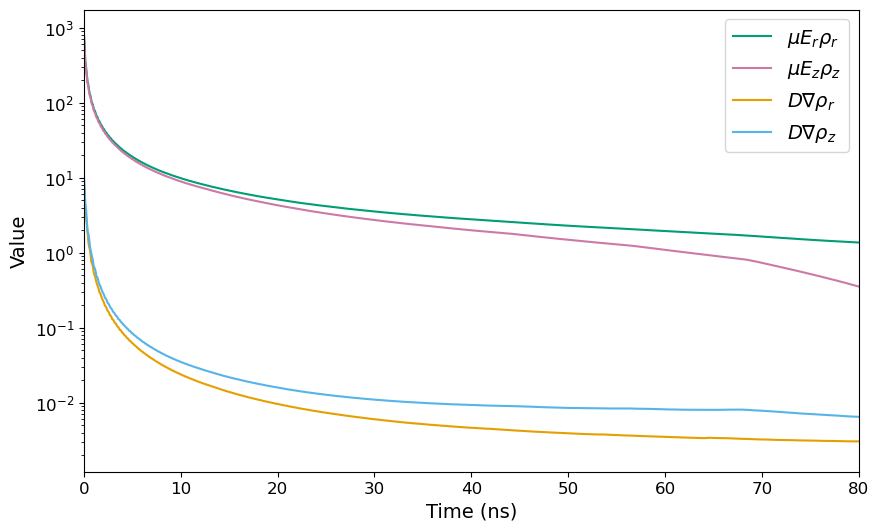

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load data: skip comment lines
data = np.loadtxt("/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/max_drift_diffusion.log", comments="#")

# Extract columns
time_ns = data[:, 1]
max_DgradR = data[:, 2]
max_DgradZ = data[:, 3]
max_vRrho = data[:, 4]
max_vZrho = data[:, 5]

# Estimate time step from differences
time_step = np.diff(time_ns, prepend=time_ns[0])

# Use colorblind-friendly colors (Color Universal Design)
colors = {
    "DgradR": "#E69F00",    # orange
    "DgradZ": "#56B4E9",    # light blue
    "vRrho":  "#009E73",    # bluish green
    "vZrho":  "#CC79A7"     # reddish purple
}

plt.rcParams.update({'font.size': 14})

# Plot 1: All terms
plt.figure(figsize=(10, 6))
plt.plot(time_ns, max_vRrho, label=r"$\mu E_r \rho_r$", color=colors["vRrho"])
plt.plot(time_ns, max_vZrho, label=r"$\mu E_z \rho_z$", color=colors["vZrho"])
plt.plot(time_ns, max_DgradR, label=r"$D\nabla\rho_r$", color=colors["DgradR"])
plt.plot(time_ns, max_DgradZ, label=r"$D\nabla\rho_z$", color=colors["DgradZ"])
plt.xlim(0, 80)
plt.yscale('log')
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("Value", fontsize=14)
# plt.title("Components of EH-Drift PDEs", fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
plt.savefig('figs/ehd_pde_comps.pdf')
plt.show()
